In [25]:
import os
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer, StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

SEED = 42
MIN_OBSERVED_TARGETS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_global_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


def reset_run_seed(seed: int = SEED):
    """Reset all RNGs before each major run stage (tuning, training, evaluation)."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    set_global_seed(seed)


reset_run_seed(SEED)

X_cols = [
    "Construction period",
    "Typology",
    "Primary Code",
    "Hybrid Structure",
    "Country",
]

y_cols = ["Concrete", "Glass", "Steel", "Wood", "Brick"]

In [45]:
QUANTILES = [0.05, 0.50, 0.95]  # p5, p50, p95


def split_inputs(x_full: torch.Tensor, structure_dim: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Split encoded features into trunk input and explicit structure features."""
    if structure_dim <= 0 or structure_dim >= x_full.shape[1]:
        raise ValueError(
            f"Invalid structure_dim={structure_dim} for input width={x_full.shape[1]}"
        )
    x_all = x_full[:, :-structure_dim]
    x_structure = x_full[:, -structure_dim:]
    return x_all, x_structure


class JointQuantileNet(nn.Module):
    """
    Shared-trunk multi-task quantile network with lightweight material interaction.

    The model first builds material-specific latent states from a shared feature vector,
    then applies one message-passing step across materials before per-material heads.
    """

    def __init__(
        self,
        input_dim: int,
        structure_dim: int,
        M: int = 5,
        hidden_dim: int = 256,
    ):
        super().__init__()
        self.M = M
        self.structure_dim = structure_dim
        self.hidden_dim = hidden_dim

        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        # Build a base feature that will be specialized per material.
        self.base_feature = nn.Linear(hidden_dim + structure_dim, hidden_dim)
        self.material_embeddings = nn.Parameter(torch.randn(M, hidden_dim) * 0.02)

        # Lightweight message passing (single attention-style interaction step).
        self.msg_query = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.msg_key = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.msg_value = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.msg_gate = nn.Linear(hidden_dim * 2, hidden_dim)

        self.heads = nn.ModuleList([nn.Linear(hidden_dim, 3) for _ in range(M)])

    def forward(self, x_all: torch.Tensor, x_structure: torch.Tensor) -> torch.Tensor:
        """
        Returns
        -------
        quantiles : Tensor of shape (batch, M, 3)
            dim-2 order: [p5, p50, p95]
        """
        h = self.trunk(x_all)
        h_concat = torch.cat([h, x_structure], dim=1)

        base = self.base_feature(h_concat)  # (B, H)
        z0 = base.unsqueeze(1) + self.material_embeddings.unsqueeze(0)  # (B, M, H)

        q = self.msg_query(z0)
        k = self.msg_key(z0)
        v = self.msg_value(z0)
        attn_logits = torch.matmul(q, k.transpose(-1, -2)) / np.sqrt(self.hidden_dim)
        attn_weights = torch.softmax(attn_logits, dim=-1)
        msg = torch.matmul(attn_weights, v)

        gate = torch.sigmoid(self.msg_gate(torch.cat([z0, msg], dim=-1)))
        z = gate * msg + (1.0 - gate) * z0  # (B, M, H)

        per_material = [head(z[:, m, :]) for m, head in enumerate(self.heads)]
        raw = torch.stack(per_material, dim=1)  # (B, M, 3)

        q50 = raw[:, :, 0]  # (batch, M)
        delta_low = F.softplus(raw[:, :, 1]) + 1e-4  # positive spread
        delta_high = F.softplus(raw[:, :, 2]) + 1e-4

        q5 = q50 - delta_low
        q95 = q50 + delta_high

        return torch.stack([q5, q50, q95], dim=-1)  # (batch, M, 3)


In [27]:
def quantile_loss(
    y_pred: torch.Tensor,   # (batch, M, 3)  — [p5, p50, p95] in transformed space
    y_true: torch.Tensor,   # (batch, M)     — transformed targets, 0 where unobserved
    y_mask: torch.Tensor,   # (batch, M) bool
) -> torch.Tensor:
    """
    Masked pinball (quantile) loss averaged over observed (material, quantile) pairs.

    For each observed (row, material) pair the pinball loss is computed for
    all three quantile levels and summed. Unobserved materials contribute
    zero to the numerator and denominator.
    """
    q_levels = y_true.new_tensor(QUANTILES)          # (3,)
    y_true_exp = y_true.unsqueeze(-1)                # (batch, M, 1)

    errors = y_true_exp - y_pred                     # (batch, M, 3)
    pinball = torch.where(
        errors >= 0,
        q_levels * errors,
        (q_levels - 1) * errors,
    )                                                # (batch, M, 3)

    mask = y_mask.unsqueeze(-1).float()              # (batch, M, 1)
    masked_sum = (pinball * mask).sum()
    n_observed = mask.sum() * len(QUANTILES)

    return masked_sum / (n_observed + 1e-8)

In [28]:
def fit_target_transformers(y_train_raw, y_train_mask):
    transformers = {}

    for idx, material in enumerate(y_cols):
        observed = y_train_mask[:, idx]
        if not np.any(observed):
            transformers[material] = None
            continue

        observed_targets = y_train_raw[observed, idx].reshape(-1, 1)
        transformer = QuantileTransformer(
            n_quantiles=min(1000, observed_targets.shape[0]),
            output_distribution="normal",
            random_state=SEED,
        )
        transformer.fit(observed_targets)
        transformers[material] = transformer

    return transformers


def transform_targets(y_raw, y_mask, target_transformers):
    transformed = np.zeros_like(y_raw, dtype=np.float32)

    for idx, material in enumerate(y_cols):
        observed = y_mask[:, idx]
        if not np.any(observed):
            continue

        transformer = target_transformers.get(material)
        observed_targets = y_raw[observed, idx].reshape(-1, 1)
        if transformer is None:
            transformed[observed, idx] = observed_targets[:, 0].astype(np.float32)
            continue

        transformed[observed, idx] = transformer.transform(observed_targets)[:, 0].astype(
            np.float32
        )

    return transformed


def prepare_dataloaders(
    file_path: str | Path = "Integrated_MI_database_add_Singapore.xlsx",
    batch_size: int = 64,
    random_state: int = SEED,
    clip_upper_quantile: float | None = 0.99,
    clip_materials: tuple[str, ...] = ("Steel", "Glass", "Concrete", "Brick", "Wood"),
    min_observed_targets: int = MIN_OBSERVED_TARGETS,
):
    file_path = Path(file_path)
    if not file_path.is_absolute():
        file_path = Path.cwd() / file_path

    df = pd.read_excel(file_path)

    df["Construction period"] = pd.to_numeric(
        df["Construction period"], errors="coerce"
    )
    df = df.dropna(subset=X_cols).reset_index(drop=True)

    target_mask_df = df[y_cols].notna()
    df = df.loc[target_mask_df.sum(axis=1) >= min_observed_targets].reset_index(drop=True)

    X = df[X_cols].copy()
    y_raw_df = df[y_cols].copy()
    y_mask = y_raw_df.notna().to_numpy(dtype=bool)

    split_data = train_test_split(
        X, y_raw_df, y_mask, test_size=0.30, random_state=random_state
    )
    X_train, X_temp, y_train_raw_df, y_temp_raw_df, y_train_mask, y_temp_mask = split_data

    split_temp = train_test_split(
        X_temp, y_temp_raw_df, y_temp_mask, test_size=0.50, random_state=random_state
    )
    X_val, X_test, y_val_raw_df, y_test_raw_df, y_val_mask, y_test_mask = split_temp

    X_train = X_train.reset_index(drop=True)
    X_val = X_val.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train_raw_df = y_train_raw_df.reset_index(drop=True)
    y_val_raw_df = y_val_raw_df.reset_index(drop=True)
    y_test_raw_df = y_test_raw_df.reset_index(drop=True)

    y_train_raw = np.array(y_train_raw_df.to_numpy(dtype=np.float32), copy=True)
    y_val_raw = np.array(y_val_raw_df.to_numpy(dtype=np.float32), copy=True)
    y_test_raw = np.array(y_test_raw_df.to_numpy(dtype=np.float32), copy=True)

    clip_bounds = None
    if clip_upper_quantile is not None:
        if not (0.0 <= clip_upper_quantile <= 1.0):
            raise ValueError("clip_upper_quantile must satisfy 0 <= q <= 1")

        material_to_idx = {material: idx for idx, material in enumerate(y_cols)}
        selected_materials = [
            material for material in clip_materials if material in material_to_idx
        ]

        upper_bounds = {}
        for material in selected_materials:
            idx = material_to_idx[material]
            observed_train = y_train_mask[:, idx]
            if not np.any(observed_train):
                continue

            upper_bound = np.quantile(
                y_train_raw[observed_train, idx], clip_upper_quantile
            )

            for target_array, target_mask in (
                (y_train_raw, y_train_mask),
                (y_val_raw, y_val_mask),
                (y_test_raw, y_test_mask),
            ):
                observed_rows = target_mask[:, idx]
                target_array[observed_rows, idx] = np.minimum(
                    target_array[observed_rows, idx], upper_bound
                )

            upper_bounds[material] = float(upper_bound)

        clip_bounds = {
            "upper_quantile": clip_upper_quantile,
            "upper_bounds": upper_bounds,
        }

    y_train_filled = np.nan_to_num(y_train_raw, nan=0.0)
    y_val_filled = np.nan_to_num(y_val_raw, nan=0.0)
    y_test_filled = np.nan_to_num(y_test_raw, nan=0.0)

    target_transformers = fit_target_transformers(y_train_filled, y_train_mask)
    y_train = transform_targets(y_train_filled, y_train_mask, target_transformers)
    y_val = transform_targets(y_val_filled, y_val_mask, target_transformers)
    y_test = transform_targets(y_test_filled, y_test_mask, target_transformers)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), ["Construction period"]),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                ["Typology", "Primary Code", "Hybrid Structure", "Country"],
            ),
        ]
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_val)
    X_test_processed = preprocessor.transform(X_test)

    structure_dim = len(preprocessor.named_transformers_["cat"].categories_[2])

    X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    y_train_mask_tensor = torch.tensor(y_train_mask, dtype=torch.bool)
    y_val_mask_tensor = torch.tensor(y_val_mask, dtype=torch.bool)
    y_test_mask_tensor = torch.tensor(y_test_mask, dtype=torch.bool)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor, y_train_mask_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor, y_val_mask_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor, y_test_mask_tensor)

    loader_kwargs = {"pin_memory": torch.cuda.is_available()}
    train_generator = torch.Generator().manual_seed(random_state)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=train_generator,
        **loader_kwargs,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs
    )

    return {
        "X_train": X_train_tensor,
        "X_val": X_val_tensor,
        "X_test": X_test_tensor,
        "y_train": y_train_tensor,
        "y_val": y_val_tensor,
        "y_test": y_test_tensor,
        "y_train_mask": y_train_mask_tensor,
        "y_val_mask": y_val_mask_tensor,
        "y_test_mask": y_test_mask_tensor,
        "y_val_raw_df": y_val_raw_df,
        "y_test_raw_df": y_test_raw_df,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "preprocessor": preprocessor,
        "target_transformers": target_transformers,
        "clip_bounds": clip_bounds,
        "kept_rows": len(df),
        "min_observed_targets": min_observed_targets,
        "structure_dim": structure_dim,
    }

In [29]:
data = prepare_dataloaders()
print("Data preparation complete.")
print(f"X_train shape: {data['X_train'].shape}, y_train shape: {data['y_train'].shape}")
print(f"X_val shape:   {data['X_val'].shape}, y_val shape:   {data['y_val'].shape}")
print(f"X_test shape:  {data['X_test'].shape}, y_test shape:  {data['y_test'].shape}")
print(
    f"Rows kept with >= {data['min_observed_targets']} observed targets: {data['kept_rows']}"
 )

for split in ["train", "val", "test"]:
    mask = data[f"y_{split}_mask"].cpu().numpy()
    observed_counts = mask.sum(axis=1)
    print(
        f"{split.title()} observed targets per row - "
        f"min: {observed_counts.min()}, "
        f"mean: {observed_counts.mean():.2f}, "
        f"max: {observed_counts.max()}"
    )

Data preparation complete.
X_train shape: torch.Size([1799, 47]), y_train shape: torch.Size([1799, 5])
X_val shape:   torch.Size([385, 47]), y_val shape:   torch.Size([385, 5])
X_test shape:  torch.Size([386, 47]), y_test shape:  torch.Size([386, 5])
Rows kept with >= 2 observed targets: 2570
Train observed targets per row - min: 2, mean: 3.65, max: 5
Val observed targets per row - min: 2, mean: 3.57, max: 5
Test observed targets per row - min: 2, mean: 3.69, max: 5


In [30]:
def quantile_loss(pred_q, target, q):
    e = target - pred_q
    return torch.maximum((q - 1) * e, q * e)


def masked_multi_quantile_loss(preds, y, mask, quantiles=QUANTILES):
    # preds: (B, M, Q), y/mask: (B, M)
    B, M, Q = preds.shape
    losses = []
    valid_count = 0

    for m in range(M):
        m_mask = mask[:, m]  # (B,)
        if m_mask.any():
            y_m = y[m_mask, m]  # (N,)
            pred_m = preds[m_mask, m, :]  # (N, Q)
            lq = 0.0
            for qi, q in enumerate(quantiles):
                lq = lq + quantile_loss(pred_m[:, qi], y_m, q).mean()
            losses.append(lq / Q)
            valid_count += 1

    if valid_count == 0:
        return torch.tensor(0.0, device=preds.device, requires_grad=True)

    return torch.stack(losses).mean()


def train_one_epoch(model, loader, optimizer, structure_dim: int):
    model.train()
    total = 0.0
    n = 0
    for X_batch, y_batch, m_batch in loader:
        X_batch = X_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        m_batch = m_batch.to(DEVICE, non_blocking=True)

        x_all, x_structure = split_inputs(X_batch, structure_dim)
        optimizer.zero_grad(set_to_none=True)
        preds = model(x_all, x_structure)
        loss = masked_multi_quantile_loss(preds, y_batch, m_batch)
        loss.backward()
        optimizer.step()

        total += loss.item() * X_batch.size(0)
        n += X_batch.size(0)
    return total / max(n, 1)


def evaluate_loss(model, loader, structure_dim: int):
    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for X_batch, y_batch, m_batch in loader:
            X_batch = X_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            m_batch = m_batch.to(DEVICE, non_blocking=True)

            x_all, x_structure = split_inputs(X_batch, structure_dim)
            preds = model(x_all, x_structure)
            loss = masked_multi_quantile_loss(preds, y_batch, m_batch)

            total += loss.item() * X_batch.size(0)
            n += X_batch.size(0)
    return total / max(n, 1)


def objective(trial):
    # Make each trial fully reproducible while keeping trials distinct.
    reset_run_seed(SEED + trial.number)

    tuned_data = prepare_dataloaders(batch_size=trial.suggest_categorical("batch_size", [32, 64, 128]))

    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 384])
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    wd = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    structure_dim = tuned_data["structure_dim"]
    input_dim = tuned_data["X_train"].shape[1] - structure_dim
    model = JointQuantileNet(
        input_dim=input_dim,
        structure_dim=structure_dim,
        M=5,
        hidden_dim=hidden_dim,
    ).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    best_val = float("inf")
    epochs = 80
    for _ in range(epochs):
        _ = train_one_epoch(model, tuned_data["train_loader"], optimizer, structure_dim)
        val = evaluate_loss(model, tuned_data["val_loader"], structure_dim)
        if val < best_val:
            best_val = val

    return best_val


# Reset once before hyperparameter search and use a seeded sampler.
reset_run_seed(SEED)
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
n_trials = 20
trial_progress = tqdm(total=n_trials, desc="Optuna trials", leave=True)

def _progress_callback(study, trial):
    trial_progress.update(1)

study.optimize(objective, n_trials=n_trials, callbacks=[_progress_callback])
trial_progress.close()

print("Best trial:")
print(study.best_trial.params)
best_params = study.best_trial.params

# Retrain best model on train split and monitor val with fixed seed.
reset_run_seed(SEED)
model = JointQuantileNet(
    input_dim=data["X_train"].shape[1] - data["structure_dim"],
    structure_dim=data["structure_dim"],
    M=5,
    hidden_dim=best_params["hidden_dim"],
).to(DEVICE)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"],
)

best_state_dict = None
best_val_loss = float("inf")
epochs = 120

final_epoch_progress = tqdm(range(1, epochs + 1), desc="Final training", leave=True)
for epoch in final_epoch_progress:
    train_loss = train_one_epoch(model, data["train_loader"], optimizer, data["structure_dim"])
    val_loss = evaluate_loss(model, data["val_loader"], data["structure_dim"])
    final_epoch_progress.set_postfix(train_loss=f"{train_loss:.4f}", val_loss=f"{val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

print(f"Best validation loss: {best_val_loss:.6f}")

[I 2026-05-01 19:38:01,924] A new study created in memory with name: no-name-701995b8-967f-4564-a98c-bb89a3412ed0


Optuna trials:   0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-01 19:38:19,983] Trial 0 finished with value: 0.15991713036964467 and parameters: {'batch_size': 64, 'hidden_dim': 128, 'lr': 0.00012184186502221769, 'weight_decay': 0.0003967605077052988}. Best is trial 0 with value: 0.15991713036964467.
[I 2026-05-01 19:38:37,833] Trial 1 finished with value: 0.15778125659985975 and parameters: {'batch_size': 64, 'hidden_dim': 128, 'lr': 0.00018559980846490597, 'weight_decay': 3.549878832196506e-06}. Best is trial 1 with value: 0.15778125659985975.
[I 2026-05-01 19:38:56,458] Trial 2 finished with value: 0.15590691442613477 and parameters: {'batch_size': 64, 'hidden_dim': 256, 'lr': 0.00027010527749605503, 'weight_decay': 1.2562773503807034e-05}. Best is trial 2 with value: 0.15590691442613477.
[I 2026-05-01 19:39:15,304] Trial 3 finished with value: 0.15043962497215765 and parameters: {'batch_size': 64, 'hidden_dim': 256, 'lr': 0.0007896186801026692, 'weight_decay': 3.247673570627449e-06}. Best is trial 3 with value: 0.15043962497215765.


Best trial:
{'batch_size': 32, 'hidden_dim': 384, 'lr': 0.002204236859600847, 'weight_decay': 6.218799398113023e-05}


Final training:   0%|          | 0/120 [00:00<?, ?it/s]

Best validation loss: 0.146468


In [31]:
def inverse_transform_quantiles(quantiles, target_transformers=None):
    if target_transformers is None:
        return np.expm1(quantiles)

    restored = np.empty_like(quantiles, dtype=np.float32)
    for m, material in enumerate(y_cols):
        transformer = target_transformers.get(material)
        material_quantiles = quantiles[:, m, :]
        if transformer is None:
            restored[:, m, :] = material_quantiles.astype(np.float32)
            continue

        for q_idx in range(material_quantiles.shape[1]):
            restored[:, m, q_idx] = transformer.inverse_transform(
                material_quantiles[:, q_idx].reshape(-1, 1)
            )[:, 0].astype(np.float32)

    return restored


def predict_material_ranges(
    model,
    X_new_tensor,
    structure_dim: int,
    target_transformers=None,
    conformal_qhats=None,
    quantiles=QUANTILES,
):
    model.eval()
    with torch.no_grad():
        X_new = X_new_tensor.to(DEVICE)
        x_all, x_structure = split_inputs(X_new, structure_dim)
        q_pred = model(x_all, x_structure).cpu().numpy()  # (N, M, 3) in transformed space

    restored_quantiles = inverse_transform_quantiles(
        q_pred, target_transformers=target_transformers
    )
    q5 = restored_quantiles[:, :, 0]
    q50 = restored_quantiles[:, :, 1]
    q95 = restored_quantiles[:, :, 2]

    if conformal_qhats is not None:
        for m, material in enumerate(y_cols):
            qhat = float(conformal_qhats.get(material, 0.0))
            q5[:, m] = np.maximum(q5[:, m] - qhat, 0.0)
            q95[:, m] = q95[:, m] + qhat

    out = {}
    for m, material in enumerate(y_cols):
        out[material] = {
            "p5": q5[:, m],
            "p50": q50[:, m],
            "p95": q95[:, m],
        }
    return out


if (not isinstance(data, dict)) or ("X_test" not in data) or ("structure_dim" not in data):
    print("Rebuilding dataset dictionary because `data` was overwritten in kernel state.")
    data = prepare_dataloaders()

existing_conformal_qhats = globals().get("conformal_qhats")
pred_ranges = predict_material_ranges(
    model,
    data["X_test"],
    structure_dim=data["structure_dim"],
    target_transformers=data.get("target_transformers"),
    conformal_qhats=existing_conformal_qhats,
)
for material in y_cols:
    print(
        material,
        "median first3:",
        np.round(pred_ranges[material]["p50"][:3], 3),
        "range first3:",
        np.round(pred_ranges[material]["p5"][:3], 3),
        "-",
        np.round(pred_ranges[material]["p95"][:3], 3),
    )

Concrete median first3: [1125.32  1361.022  728.044] range first3: [274.483 534.706 196.866] - [1885.727 2372.294 1504.89 ]
Glass median first3: [2.957 1.915 2.   ] range first3: [0.704 0.267 0.634] - [8.376 6.66  3.938]
Steel median first3: [22.81  29.882 14.   ] range first3: [2.88  5.117 0.   ] - [56.147 90.299 26.771]
Wood median first3: [16.206  5.994  8.891] range first3: [0. 0. 0.] - [74.075 52.982 32.256]
Brick median first3: [191.207 138.449 642.464] range first3: [28.797  0.    96.408] - [ 740.466  719.203 1085.042]


In [32]:
def fit_conformal_qhats(
    model,
    X_calib_tensor,
    y_calib_raw_df,
    alpha=0.10,
    structure_dim: int = 1,
    target_transformers=None,
):
    """
    Split-conformal calibration on val set using CQR nonconformity scores.

    scores_i = max(q_lo(x_i) - y_i, y_i - q_hi(x_i)) on the original target scale.
    Note: scores can be negative if y_i lies well inside [q_lo, q_hi], which enables
    interval shrinking when appropriate.
    """
    base_pred = predict_material_ranges(
        model,
        X_calib_tensor,
        structure_dim=structure_dim,
        target_transformers=target_transformers,
    )
    qhats = {}

    for material in y_cols:
        y_obs = y_calib_raw_df[material].to_numpy(dtype=float)
        mask = ~np.isnan(y_obs)
        if mask.sum() == 0:
            qhats[material] = 0.0
            continue

        lo = base_pred[material]["p5"][mask]
        hi = base_pred[material]["p95"][mask]
        yv = y_obs[mask]

        scores = np.maximum(lo - yv, yv - hi)

        n = scores.shape[0]
        q_level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
        qhat = float(np.quantile(scores, q_level, method="higher"))
        qhats[material] = qhat

    return qhats


def evaluate_conformal_coverage(
    model,
    X_tensor,
    y_raw_df,
    qhats,
    structure_dim: int,
    target_transformers=None,
):
    pred = predict_material_ranges(
        model,
        X_tensor,
        structure_dim=structure_dim,
        target_transformers=target_transformers,
        conformal_qhats=qhats,
    )
    rows = []

    for material in y_cols:
        y_obs = y_raw_df[material].to_numpy(dtype=float)
        mask = ~np.isnan(y_obs)
        if mask.sum() == 0:
            rows.append(
                {
                    "material": material,
                    "coverage": np.nan,
                    "mean_interval_width": np.nan,
                    "n_obs": 0,
                }
            )
            continue

        lo = pred[material]["p5"][mask]
        hi = pred[material]["p95"][mask]
        yv = y_obs[mask]

        coverage = np.mean((yv >= lo) & (yv <= hi))
        mean_width = np.mean(hi - lo)

        rows.append(
            {
                "material": material,
                "coverage": coverage,
                "mean_interval_width": mean_width,
                "n_obs": int(mask.sum()),
            }
        )

    return pd.DataFrame(rows)


conformal_qhats = fit_conformal_qhats(
    model,
    data["X_val"],
    data["y_val_raw_df"],
    alpha=0.10,
    structure_dim=data["structure_dim"],
    target_transformers=data.get("target_transformers"),
)
print("Conformal qhats:")
for k, v in conformal_qhats.items():
    print(f"  {k}: {v:.4f}")

val_cov = evaluate_conformal_coverage(
    model,
    data["X_val"],
    data["y_val_raw_df"],
    conformal_qhats,
    structure_dim=data["structure_dim"],
    target_transformers=data.get("target_transformers"),
)
test_cov = evaluate_conformal_coverage(
    model,
    data["X_test"],
    data["y_test_raw_df"],
    conformal_qhats,
    structure_dim=data["structure_dim"],
    target_transformers=data.get("target_transformers"),
)

print("\nValidation conformal coverage (target ~0.90):")
display(val_cov)
print("\nTest conformal coverage:")
display(test_cov)

conformal_bundle = {
    "alpha": 0.10,
    "qhats": conformal_qhats,
    "val_coverage": val_cov,
    "test_coverage": test_cov,
}

Conformal qhats:
  Concrete: 17.6851
  Glass: 0.4200
  Steel: 0.8016
  Wood: 0.4080
  Brick: 2.0177

Validation conformal coverage (target ~0.90):


,material,coverage,mean_interval_width,n_obs
0,Concrete,0.907801,2109.521240,282
1,Glass,0.909091,5.383986,176
2,Steel,0.906977,93.131302,344
3,Wood,0.908228,50.001118,316
4,Brick,0.910506,969.766724,257



Test conformal coverage:


,material,coverage,mean_interval_width,n_obs
0,Concrete,0.868687,2135.194336,297
1,Glass,0.891192,5.423317,193
2,Steel,0.901734,85.626839,346
3,Wood,0.920128,47.085358,313
4,Brick,0.927798,968.655579,277


Conformal qhats: {'Concrete': 17.68505859375, 'Glass': 0.41996890235461404, 'Steel': 0.8015718997179806, 'Wood': 0.40799998688697814, 'Brick': 2.0176924781791996}


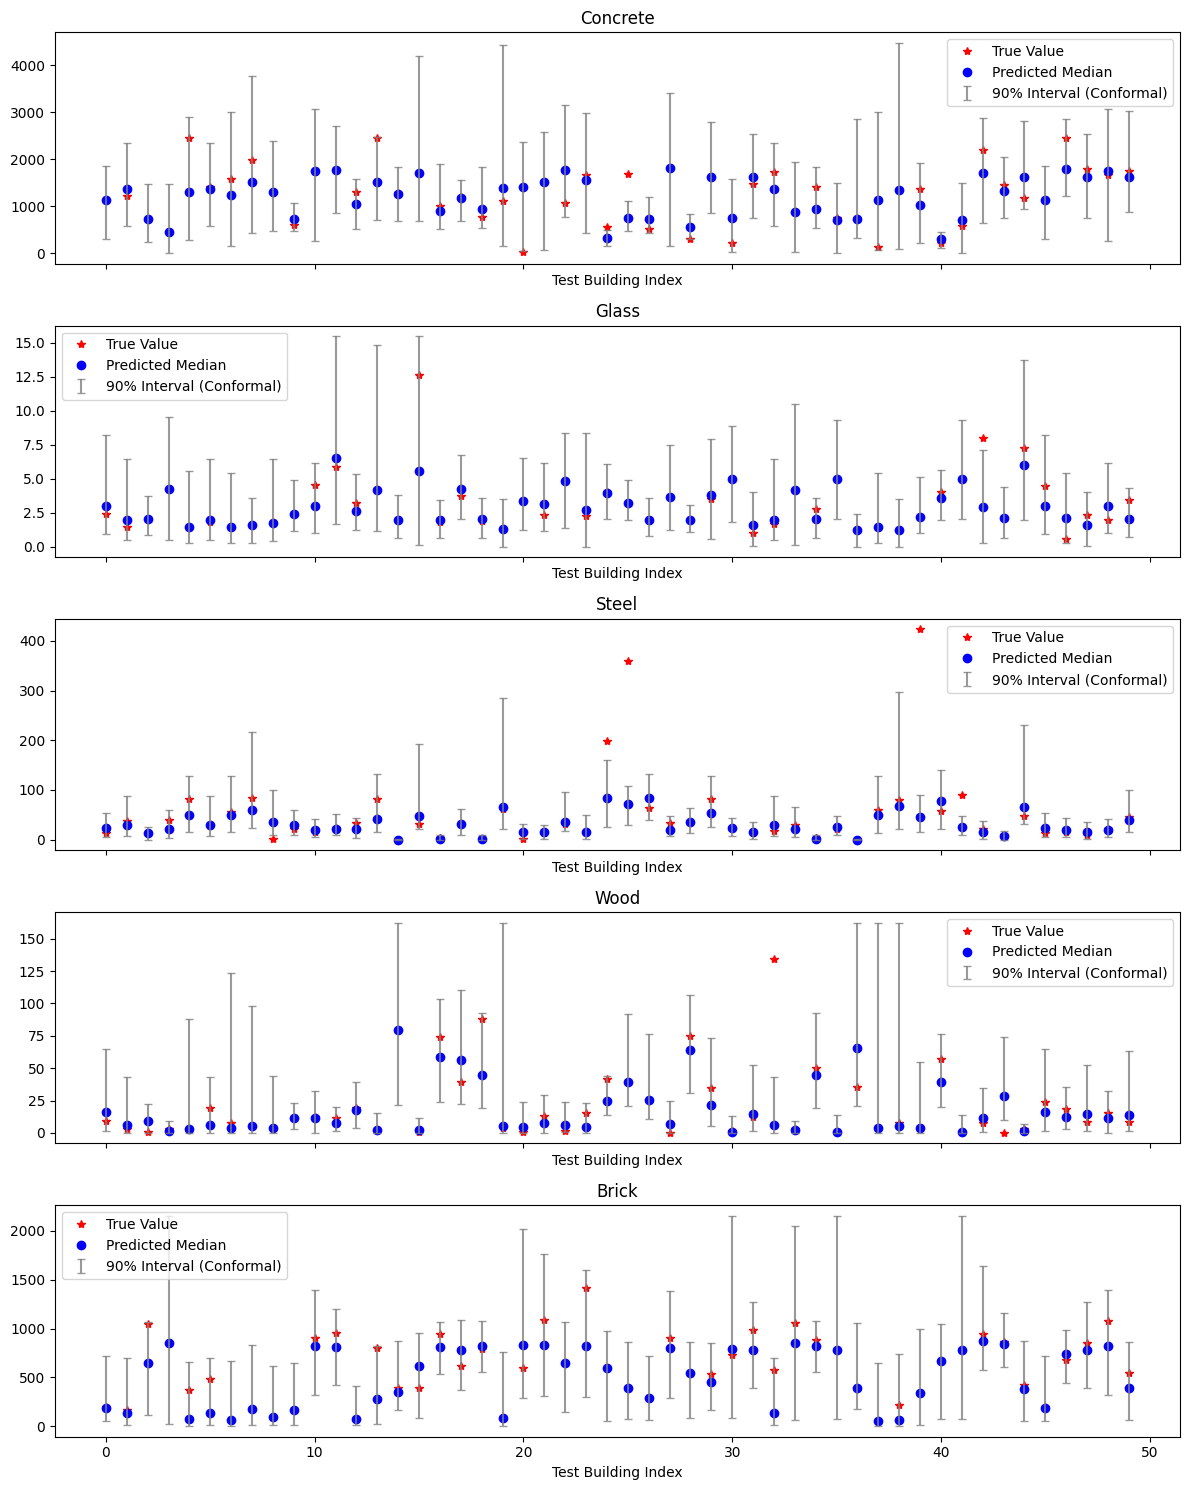

In [33]:
import matplotlib.pyplot as plt

# Validation split is used as calibration data for split-conformal intervals.
y_val_df = data["y_val_raw_df"].copy()
conformal_qhats = fit_conformal_qhats(
    model,
    data["X_val"],
    y_val_df,
    alpha=0.10,
    structure_dim=data["structure_dim"],
    target_transformers=data.get("target_transformers"),
)
conformal_bundle = {"alpha": 0.10, "qhats": conformal_qhats}
print("Conformal qhats:", conformal_qhats)

y_test_df = data["y_test_raw_df"].copy()
y_test_mask = data["y_test_mask"].cpu().numpy()

X_test_first50 = data["X_test"][:50]
pred_ranges = predict_material_ranges(
    model,
    X_test_first50,
    structure_dim=data["structure_dim"],
    target_transformers=data.get("target_transformers"),
    conformal_qhats=conformal_qhats,
)

fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
x_idx = np.arange(50)

for i, material in enumerate(y_cols):
    ax = axes[i]
    y_true = np.array(y_test_df[material].iloc[:50].to_numpy(dtype=float), copy=True)
    observed = y_test_mask[:50, i].astype(bool)
    y_true[~observed] = np.nan

    y_med = pred_ranges[material]["p50"]
    y_low = pred_ranges[material]["p5"]
    y_high = pred_ranges[material]["p95"]

    ax.plot(x_idx, y_true, "r*", label="True Value")
    ax.plot(x_idx, y_med, "bo", label="Predicted Median")
    ax.errorbar(
        x_idx,
        y_med,
        yerr=[np.maximum(y_med - y_low, 0), np.maximum(y_high - y_med, 0)],
        fmt="none",
        ecolor="gray",
        alpha=0.8,
        capsize=3,
        label="90% Interval (Conformal)",
    )

    ax.set_title(material)
    ax.set_xlabel("Test Building Index")
    ax.legend()

plt.tight_layout()
plt.show()

Joint distribution summary:
  split: test
  n_complete_rows: 135
  mean_vector_mae: 35.581672
  cov_fro_norm: 276183.638369
  corr_fro_norm: 1.296656
  kl_true_to_pred: 71.519661
  kl_pred_to_true: 3.299326

Per-material moments (complete-case rows):


,material,true_mean,pred_mean,abs_mean_diff,true_std,pred_std,abs_std_diff
0,Concrete,1654.170734,1525.704834,128.465900,636.373380,364.827026,271.546353
1,Glass,2.943218,2.731139,0.212078,2.464706,1.226961,1.237745
2,Steel,27.906512,22.153954,5.752558,63.269427,13.630815,49.638613
3,Wood,23.603882,17.288557,6.315325,23.055424,14.825672,8.229752
4,Brick,682.684163,645.521667,37.162496,300.128005,229.311020,70.816985


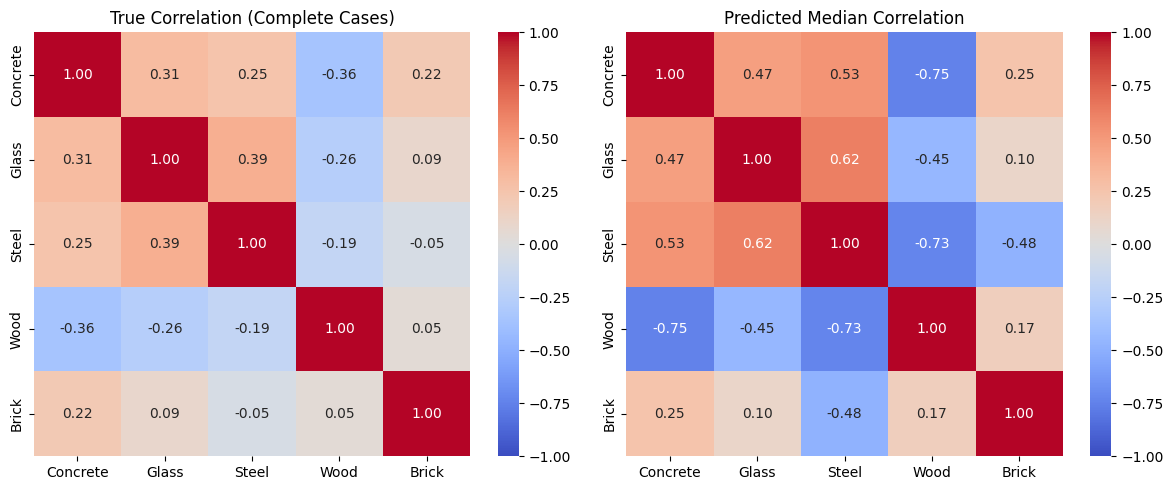

In [34]:
def _gaussian_kl(mu_p, cov_p, mu_q, cov_q, eps=1e-6):
    d = mu_p.shape[0]
    cov_p_reg = cov_p + np.eye(d) * eps
    cov_q_reg = cov_q + np.eye(d) * eps

    sign_p, logdet_p = np.linalg.slogdet(cov_p_reg)
    sign_q, logdet_q = np.linalg.slogdet(cov_q_reg)
    if sign_p <= 0 or sign_q <= 0:
        return np.nan

    inv_q = np.linalg.inv(cov_q_reg)
    mean_term = (mu_q - mu_p).T @ inv_q @ (mu_q - mu_p)
    trace_term = np.trace(inv_q @ cov_p_reg)
    return 0.5 * (trace_term + mean_term - d + (logdet_q - logdet_p))


def evaluate_joint_distribution(
    model,
    data,
    split="test",
    structure_dim: int = 1,
    min_complete_rows: int = 30,
    target_transformers=None,
):
    y_df = data[f"y_{split}_raw_df"][y_cols].copy()
    complete_mask = y_df.notna().all(axis=1).to_numpy()
    n_complete = int(complete_mask.sum())

    if n_complete < min_complete_rows:
        raise ValueError(
            f"Not enough complete rows for joint evaluation: {n_complete} < {min_complete_rows}"
        )

    pred_ranges_full = predict_material_ranges(
        model,
        data[f"X_{split}"],
        structure_dim=structure_dim,
        target_transformers=target_transformers,
        conformal_qhats=None,
    )

    pred_med_full = np.column_stack([pred_ranges_full[m]["p50"] for m in y_cols])
    y_true_full = y_df.to_numpy(dtype=float)

    y_true = y_true_full[complete_mask]
    y_pred = pred_med_full[complete_mask]

    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    std_true = y_true.std(axis=0, ddof=1)
    std_pred = y_pred.std(axis=0, ddof=1)

    cov_true = np.cov(y_true, rowvar=False)
    cov_pred = np.cov(y_pred, rowvar=False)
    corr_true = np.corrcoef(y_true, rowvar=False)
    corr_pred = np.corrcoef(y_pred, rowvar=False)

    summary = {
        "split": split,
        "n_complete_rows": n_complete,
        "mean_vector_mae": float(np.mean(np.abs(mu_true - mu_pred))),
        "cov_fro_norm": float(np.linalg.norm(cov_true - cov_pred, ord="fro")),
        "corr_fro_norm": float(np.linalg.norm(corr_true - corr_pred, ord="fro")),
        "kl_true_to_pred": float(_gaussian_kl(mu_true, cov_true, mu_pred, cov_pred)),
        "kl_pred_to_true": float(_gaussian_kl(mu_pred, cov_pred, mu_true, cov_true)),
    }

    per_material = pd.DataFrame(
        {
            "material": y_cols,
            "true_mean": mu_true,
            "pred_mean": mu_pred,
            "abs_mean_diff": np.abs(mu_true - mu_pred),
            "true_std": std_true,
            "pred_std": std_pred,
            "abs_std_diff": np.abs(std_true - std_pred),
        }
    )

    return summary, per_material, corr_true, corr_pred


joint_summary, joint_per_material, corr_true, corr_pred = evaluate_joint_distribution(
    model,
    data,
    split="test",
    structure_dim=data["structure_dim"],
    target_transformers=data.get("target_transformers"),
)

print("Joint distribution summary:")
for k, v in joint_summary.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.6f}")
    else:
        print(f"  {k}: {v}")

print("\nPer-material moments (complete-case rows):")
display(joint_per_material)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(
    corr_true,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    xticklabels=y_cols,
    yticklabels=y_cols,
    ax=axes[0],
)
axes[0].set_title("True Correlation (Complete Cases)")

sns.heatmap(
    corr_pred,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    xticklabels=y_cols,
    yticklabels=y_cols,
    ax=axes[1],
)
axes[1].set_title("Predicted Median Correlation")

plt.tight_layout()
plt.show()

In [35]:
import joblib
import json

joblib.dump(data["preprocessor"], "preprocessor.joblib")
joblib.dump(data["target_transformers"], "target_transformers.joblib")
torch.save(model.state_dict(), "model_weights.pth")

with open("best_hparams.json", "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2)

print(
    "Saved preprocessor.joblib, target_transformers.joblib, model_weights.pth, "
    "and best_hparams.json"
)

Saved preprocessor.joblib, target_transformers.joblib, model_weights.pth, and best_hparams.json


In [41]:
# ==========================================================
# Validation 1: Coverage + Width + Median MAE
# ==========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

pred_test = predict_material_ranges(
    model,
    data["X_test"],
    structure_dim=data["structure_dim"],
    target_transformers=data.get("target_transformers"),
    conformal_qhats=conformal_qhats,
)

coverage_results = []

for material in y_cols:
    y_true = data["y_test_raw_df"][material].to_numpy(dtype=float)
    observed = ~np.isnan(y_true)

    y_true = y_true[observed]

    q05 = pred_test[material]["p5"][observed]
    q50 = pred_test[material]["p50"][observed]
    q95 = pred_test[material]["p95"][observed]

    coverage = np.mean(
        (y_true >= q05) &
        (y_true <= q95)
    )

    widths = q95 - q05

    coverage_results.append({
        "material": material,
        "coverage_90": coverage,
        "mean_width": widths.mean(),
        "median_width": np.median(widths),
        "p50_mae": mean_absolute_error(y_true, q50),
    })

coverage_df = pd.DataFrame(coverage_results)

print("\n===== Coverage / Width / p50 MAE =====")
print(coverage_df)

# ==========================================================
# Validation 2: Adaptive uncertainty
# ==========================================================

from scipy.stats import pearsonr

adaptive_results = []

for material in y_cols:
    y_true = data["y_test_raw_df"][material].to_numpy(dtype=float)
    observed = ~np.isnan(y_true)

    y_true = y_true[observed]

    q50 = pred_test[material]["p50"][observed]
    q05 = pred_test[material]["p5"][observed]
    q95 = pred_test[material]["p95"][observed]

    widths = q95 - q05
    errors = np.abs(y_true - q50)

    corr, p_value = pearsonr(widths, errors)

    adaptive_results.append({
        "material": material,
        "width_error_corr": corr,
        "p_value": p_value,
    })

adaptive_df = pd.DataFrame(adaptive_results)

print("\n===== Adaptive uncertainty =====")
print(adaptive_df)

# ==========================================================
# Validation 3: Conditional coverage
# ==========================================================

conditional_results = []

for material in y_cols:
    y_true = data["y_test_raw_df"][material].to_numpy(dtype=float)
    observed = ~np.isnan(y_true)

    y_true = y_true[observed]

    q05 = pred_test[material]["p5"][observed]
    q95 = pred_test[material]["p95"][observed]

    p25 = np.quantile(y_true, 0.25)
    p75 = np.quantile(y_true, 0.75)

    regions = {
        "low": y_true < p25,
        "mid": (y_true >= p25) & (y_true <= p75),
        "high": y_true > p75,
    }

    for region_name, region_mask in regions.items():
        coverage = np.mean(
            (y_true[region_mask] >= q05[region_mask]) &
            (y_true[region_mask] <= q95[region_mask])
        )

        conditional_results.append({
            "material": material,
            "region": region_name,
            "coverage": coverage,
        })

conditional_df = pd.DataFrame(conditional_results)

print("\n===== Conditional coverage =====")
print(conditional_df)

# ==========================================================
# Validation 4: PIT-like calibration
# ==========================================================

pit_results = []

for material in y_cols:
    y_true = data["y_test_raw_df"][material].to_numpy(dtype=float)
    observed = ~np.isnan(y_true)

    y_true = y_true[observed]

    q05 = pred_test[material]["p5"][observed]
    q50 = pred_test[material]["p50"][observed]
    q95 = pred_test[material]["p95"][observed]

    below_05 = np.mean(y_true < q05)
    between_05_50 = np.mean(
        (y_true >= q05) &
        (y_true < q50)
    )
    between_50_95 = np.mean(
        (y_true >= q50) &
        (y_true <= q95)
    )
    above_95 = np.mean(y_true > q95)

    pit_results.append({
        "material": material,
        "below_05": below_05,
        "between_05_50": between_05_50,
        "between_50_95": between_50_95,
        "above_95": above_95,
    })

pit_df = pd.DataFrame(pit_results)

print("\n===== PIT-like calibration =====")
print(pit_df)

# ==========================================================
# Validation 5: Baseline comparison (robust version)
# ==========================================================

baseline_results = []

for i, material in enumerate(y_cols):

    # 从训练 target matrix 提取该材料（忽略缺失）
    train_values = data["y_train"][:, i]
    train_values = train_values[~torch.isnan(train_values)]

    train_median = float(torch.median(train_values).item()) if train_values.numel() > 0 else np.nan

    # test真实值
    test_values = data["y_test_raw_df"][material].to_numpy(dtype=float)
    observed = ~np.isnan(test_values)

    y_true = test_values[observed]
    model_pred = pred_test[material]["p50"][observed]

    # baseline: 永远预测训练集 median
    baseline_pred = np.full_like(y_true, train_median)

    baseline_mae = mean_absolute_error(
        y_true,
        baseline_pred
    )

    model_mae = mean_absolute_error(
        y_true,
        model_pred
    )

    baseline_results.append({
        "material": material,
        "baseline_mae": baseline_mae,
        "model_mae": model_mae,
        "improvement": baseline_mae - model_mae,
        "improvement_pct": (
            (baseline_mae - model_mae) / baseline_mae
            if baseline_mae > 0 else np.nan
        )
    })

baseline_df = pd.DataFrame(baseline_results)

print("\n===== Baseline comparison =====")
print(baseline_df)


===== Coverage / Width / p50 MAE =====
   material  coverage_90   mean_width  median_width     p50_mae
0  Concrete     0.868687  2135.194336   1950.314941  543.603438
1     Glass     0.891192     5.423317      5.126781    1.181284
2     Steel     0.901734    85.626839     55.291382   20.576979
3      Wood     0.920128    47.085358     34.316959   10.460795
4     Brick     0.927798   968.655579    864.789673  238.874912

===== Adaptive uncertainty =====
   material  width_error_corr       p_value
0  Concrete          0.203576  4.145998e-04
1     Glass          0.512512  2.551761e-14
2     Steel          0.234819  1.015030e-05
3      Wood          0.211653  1.617103e-04
4     Brick          0.253388  1.972330e-05

===== Conditional coverage =====
    material region  coverage
0   Concrete    low  0.743243
1   Concrete    mid  0.946309
2   Concrete   high  0.837838
3      Glass    low  0.895833
4      Glass    mid  0.979381
5      Glass   high  0.708333
6      Steel    low  0.873563
7   